Questo codice racchiude i seguenti esperimenti:


*   Pretrain ped2 - test ped2
*   Pretrain ped2 - test dataset sintetico
*   Pretrain ped2 - test MED

Utilizziamo il file di training reso disponibile dagli autori di ASTNet



#Import

In [ ]:
import os
from pathlib import Path
import shutil
import re

import cv2
from PIL import Image

import numpy as np
from scipy.io import savemat, loadmat
import scipy.io as sio

import torch

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import seaborn as sns


#1-🛠️Clonazione github e connessione a drive per reperire i frames

Non clono la repository ufficiale dell'astnet ma la rete che ho forkato nel mio account github, questo perché ci sono le modifiche necessarie per trainare e testare il modello con dataset diversi da ped2, avenue e shanghai. Oltre a questo, nel main sono state aggiunte modifiche per salvare risultati utili per i plot.

In [ ]:
%cd /content
!rm -rf astnet #Pulizia
!git clone https://github.com/marco-caruso/astnet.git
%cd astnet


/content
Cloning into 'astnet'...
remote: Enumerating objects: 671, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 671 (delta 91), reused 63 (delta 63), pack-reused 567 (from 1)
Receiving objects: 100% (671/671), 45.12 MiB | 52.86 MiB/s, done.
Resolving deltas: 100% (351/351), done.
/content/astnet


In [ ]:
# Installazione requirements dalla root come richiesto dal README astnet
!pip install -r requirements.txt

ERROR: Ignored the following yanked versions: 2.4.0
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numpy==1.21.5 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 1.18.2, 1.18.3, 1.18.4, 1.18.5, 1.19.0, 1.19.1, 1.19.2, 1.19.3, 1.19.4, 1.19.5, 1.20.0, 1.20.1, 1.20.2, 1.20.3, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.22.2, 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#2-🔗Creazione dei symlink / Copia dei frames da drive

Questo processo serve per fornire i frame (presenti su drive)  alla rete nella struttura che si aspetta

##2.1-Ped2

In [ ]:
!mkdir -p "/content/astnet/data/ped2/training"
!mkdir -p "/content/astnet/data/ped2/testing"



Creazione dei symlink

In [ ]:
!ln -s "/content/drive/MyDrive/datasets/ped2/training/frames" \
      "/content/astnet/data/ped2/training/frames"

!ln -s "/content/drive/MyDrive/datasets/ped2/testing/frames" \
      "/content/astnet/data/ped2/testing/frames"

!ln -s "/content/drive/MyDrive/datasets/ped2/ped2.mat" \
      "/content/astnet/data/ped2/ped2.mat"


Verifica: devono essere 16 per il train e 12 per il test

In [ ]:
!ls /content/astnet/data/ped2
!ls /content/astnet/data/ped2/training/frames
!ls /content/astnet/data/ped2/testing/frames


ped2.mat  testing  training
01  02	03  04	05  06	07  08	09  10	11  12	13  14	15  16
01  02	03  04	05  06	07  08	09  10	11  12


##2.2-Synth

In [ ]:
!mkdir -p "/content/astnet/data/synth/training"
!mkdir -p "/content/astnet/data/synth/testing"

Creazione dei symlink

In [ ]:
!ln -s "/content/drive/MyDrive/datasets/Synth/split_80-20-20_astnet/training/frames" \
      "/content/astnet/data/synth/training/frames"

!ln -s "/content/drive/MyDrive/datasets/Synth/split_80-20-20_astnet/testing/frames" \
      "/content/astnet/data/synth/testing/frames"

!ln -s "/content/drive/MyDrive/datasets/Synth/split_80-20-20_astnet/synth.mat" \
      "/content/astnet/data/synth/split_80-20-20_astnet.mat"

Verifica

In [ ]:
!ls /content/astnet/data/synth
!ls /content/astnet/data/synth/training/frames
!ls /content/astnet/data/synth/testing/frames

split_80-20-20_astnet.mat  testing  training
n_0001	n_0014	n_0027	n_0044	n_0056	n_0071	n_0086	n_0100	n_0116	n_0136
n_0003	n_0015	n_0028	n_0045	n_0057	n_0072	n_0087	n_0102	n_0117	n_0137
n_0004	n_0016	n_0029	n_0046	n_0058	n_0073	n_0088	n_0103	n_0118	n_0138
n_0005	n_0017	n_0030	n_0047	n_0059	n_0074	n_0089	n_0104	n_0121	n_0140
n_0006	n_0018	n_0032	n_0048	n_0060	n_0076	n_0090	n_0107	n_0122	n_0141
n_0007	n_0020	n_0034	n_0049	n_0061	n_0077	n_0091	n_0108	n_0123	n_0142
n_0008	n_0021	n_0035	n_0050	n_0063	n_0078	n_0092	n_0109	n_0124
n_0009	n_0022	n_0036	n_0051	n_0065	n_0079	n_0093	n_0110	n_0126
n_0010	n_0023	n_0037	n_0052	n_0066	n_0080	n_0094	n_0111	n_0127
n_0011	n_0024	n_0038	n_0053	n_0068	n_0081	n_0097	n_0112	n_0131
n_0012	n_0025	n_0041	n_0054	n_0069	n_0082	n_0098	n_0113	n_0133
n_0013	n_0026	n_0042	n_0055	n_0070	n_0084	n_0099	n_0115	n_0134
auto_0001      caos_0007   fight_0035  n_0033  n_0083  n_0119  n_0139
auto_0003      caos_0008   fight_0036  n_0039  n_0085  n_0120  violence_0001
backpack_0

##2.3-MED

In [ ]:
!mkdir -p "/content/astnet/data/med/testing"

In [ ]:
'''
!ln -s "/content/drive/MyDrive/datasets/med/testing/frames" \
      "/content/astnet/data/med/testing/frames"

!ln -s "/content/drive/MyDrive/datasets/med/med.mat" \
      "/content/astnet/data/med/med.mat"
'''

In [ ]:
#!ls /content/astnet/data/med
#!ls /content/astnet/data/med/testing/frames

med.mat  testing
med_0001  med_0005  med_0009  med_0013	med_0017  med_0021  med_0025  med_0029
med_0002  med_0006  med_0010  med_0014	med_0018  med_0022  med_0026  med_0030
med_0003  med_0007  med_0011  med_0015	med_0019  med_0023  med_0027  med_0031
med_0004  med_0008  med_0012  med_0016	med_0020  med_0024  med_0028


In [ ]:
print("Inizio copia dei frame:")
!cp -r "/content/drive/MyDrive/datasets/med/testing/frames" "/content/astnet/data/med/testing/frames"

print("Copia del file ground truth...")
!cp "/content/drive/MyDrive/datasets/med/med.mat" "/content/astnet/data/med/med.mat"

print("Finito")

Inizio copia dei frame:
Copia del file ground truth...
✅ Finito! Ora i file sono in locale.


#3-⚙️Training

##3.1-Ped2

Questo codice serve per trainare il modello da zero su .ped2.

In [ ]:
#!cd /content/astnet/ASTNet/
#!python train.py --cfg config/ped2_wresnet.yaml


Download del modello ASTNet pre-addestrato sul dataset UCSD Ped2 e salvataggio locale del file dei pesi per l'esecuzione della fase di test. Per questi esperimenti utilizzeremo questo.

In [ ]:
!pip -q install gdown
!gdown --id 1dmDVyAkI0FiEex3aEHDQMdgDFeBtH1Fo -O pretrained.ped2.pth

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1dmDVyAkI0FiEex3aEHDQMdgDFeBtH1Fo
From (redirected): https://drive.google.com/uc?id=1dmDVyAkI0FiEex3aEHDQMdgDFeBtH1Fo&confirm=t&uuid=53f131ef-1725-4fde-a46e-eac7af7319cc
To: /content/astnet/pretrained.ped2.pth
100% 604M/604M [00:08<00:00, 75.1MB/s]


Spostiamo il file nella stessa cartella di test.py

In [ ]:
!mv pretrained.ped2.pth /content/astnet/ASTNet/


#4-📝Testing

Operazioni preliminari per evitare errori di tipo

In [ ]:
%cd /content/astnet/ASTNet
!perl -pi -e 's/\bnp\.float\b/float/g; s/\bnp\.int\b/int/g; s/\bnp\.bool\b/bool/g; s/\bnp\.object\b/object/g' utils/anomaly_util.py

/content/astnet/ASTNet


In [ ]:
!pip install yacs

In [ ]:
!ls -lah /content/astnet/datasets/seg_weights/


ls: cannot access '/content/astnet/datasets/seg_weights/': No such file or directory


##4.1-Test ped2

* train: ped2 pretrained (16 video)
* test: ped2 (12 video)

Frame totali utilizzati nel test: 1962

In [ ]:
%cd /content/astnet/ASTNet
!python test.py \
  --cfg config/ped2_wresnet.yaml \
  --model-file pretrained.ped2.pth

/content/astnet/ASTNet
=> creating output
=> creating output/ped2/ped2_wresnet
=> creating log/ped2/wrn38/ped2_wresnet_2026-01-19-15-46
Namespace(cfg='config/ped2_wresnet.yaml', model_file='pretrained.ped2.pth', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0, 1, 2, 3), 'WORKERS': 4, 'PRINT_FREQ': 1, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/drive/MyDrive/datasets', 'DATASET': 'ped2', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 2, 'LOWER_BOUND': 100}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 120, 'RESUME': True, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [80, 100], 'LR_FACTOR': 0.5}), 'TEST': CfgNode({'BATCH_SIZE

Salvataggio del test su drive

In [ ]:
!cp -r /content/astnet/ASTNet/output/ped2 /content/drive/MyDrive/datasets/ASTNet_results/

Codice per reperire il test da drive

In [ ]:
#!rm -rf /content/astnet/ASTNet/output/ped2

!mkdir -p /content/astnet/ASTNet/output/ped2
!cp -r /content/drive/MyDrive/datasets/ASTNet_results/ped2/* /content/astnet/ASTNet/output/ped2/

# Verifica della struttura
!ls -la /content/astnet/ASTNet/output/
!ls -la /content/astnet/ASTNet/output/ped2/
!ls -la /content/astnet/ASTNet/output/ped2/ped2_wresnet/

/bin/bash: line 1: tree: command not found
total 16
drwx------ 4 root root 4096 Jan 27 10:54 .
drwxr-xr-x 9 root root 4096 Jan 27 10:50 ..
drwxr-xr-x 3 root root 4096 Jan 27 10:54 ped2
drwx------ 2 root root 4096 Jan 27 10:50 ped2_wresnet
total 12
drwxr-xr-x 3 root root 4096 Jan 27 10:54 .
drwx------ 4 root root 4096 Jan 27 10:54 ..
drwx------ 2 root root 4096 Jan 27 10:54 ped2_wresnet
total 44
drwx------ 2 root root  4096 Jan 27 10:54 .
drwxr-xr-x 3 root root  4096 Jan 27 10:54 ..
-rw------- 1 root root  2681 Jan 27 10:54 gt_list.npy
-rw------- 1 root root  1519 Jan 27 10:54 ped2_wresnet_2026-01-19-15-46_test.log
-rw------- 1 root root 17983 Jan 27 10:54 psnr_list.npy
-rw------- 1 root root  1400 Jan 27 10:54 roc_fpr.npy
-rw------- 1 root root  1400 Jan 27 10:54 roc_tpr.npy


##4.2-Test synth

* train: ped2 pretrained (16 video)
* test: synth (56 video = 28 video normali + 28 video anomali)

Suddvisione anomalie nel dataset sintetico:


*   auto: 2 video
*   backpack: 5 video
*   caos: 5 video
*   fight: 7 video
*   fire: 2 video
*   violence: 4 video
*   weapons: 3 video

Frame totali utilizzati nel test: (243-4)*56 = 13384

In [ ]:
%cd /content/astnet/ASTNet

!python test.py \
  --cfg config/synth_wresnet.yaml \
  --model-file pretrained.ped2.pth



/content/astnet/ASTNet
=> creating output/split_80-20-20_astnet/synth_wresnet
=> creating log/split_80-20-20_astnet/wrn38/synth_wresnet_2026-01-19-16-28
Namespace(cfg='config/synth_wresnet.yaml', model_file='pretrained.ped2.pth', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0, 1, 2, 3), 'WORKERS': 4, 'PRINT_FREQ': 1, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/drive/MyDrive/datasets/Synth', 'DATASET': 'split_80-20-20_astnet', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 2, 'LOWER_BOUND': 0}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 120, 'RESUME': True, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [80, 100], 'LR_FACTO

Salvataggio del test su drive

In [ ]:
!cp -r /content/astnet/ASTNet/output/synth /content/drive/MyDrive/datasets/ASTNet_results/

In [ ]:
# Copia i risultati del test sintetico da Drive
!mkdir -p /content/astnet/ASTNet/output/synth
!cp -r /content/drive/MyDrive/datasets/ASTNet_results/synth_wresnet /content/astnet/ASTNet/output/synth/

# Verifica della struttura
!ls -la /content/astnet/ASTNet/output/
!ls -la /content/astnet/ASTNet/output/synth/
!ls -la /content/astnet/ASTNet/output/synth/synth_wresnet/

total 16
drwx------ 4 root root 4096 Jan 27 11:07 .
drwxr-xr-x 9 root root 4096 Jan 27 10:50 ..
drwxr-xr-x 3 root root 4096 Jan 27 10:54 ped2
drwxr-xr-x 3 root root 4096 Jan 27 11:07 synth
total 12
drwxr-xr-x 3 root root 4096 Jan 27 11:07 .
drwx------ 4 root root 4096 Jan 27 11:07 ..
drwx------ 2 root root 4096 Jan 27 11:07 synth_wresnet
total 240
drwx------ 2 root root   4096 Jan 27 11:07 .
drwxr-xr-x 3 root root   4096 Jan 27 11:07 ..
-rw------- 1 root root  27521 Jan 27 11:07 gt_list.npy
-rw------- 1 root root 120770 Jan 27 11:07 psnr_list.npy
-rw------- 1 root root  37896 Jan 27 11:07 roc_fpr.npy
-rw------- 1 root root  37896 Jan 27 11:07 roc_tpr.npy
-rw------- 1 root root   1559 Jan 27 11:07 synth_wresnet_2026-01-19-16-28_test.log


##4.3-Test MED

In [ ]:
%cd /content/astnet/ASTNet

!python test.py \
  --cfg config/med_wresnet.yaml \
  --model-file pretrained.ped2.pth




/content/astnet/ASTNet
=> creating output
=> creating output/med/med_wresnet
=> creating log/med/wrn38/med_wresnet_2026-01-29-13-15
Namespace(cfg='config/med_wresnet.yaml', model_file='pretrained.ped2.pth', opts=[])
CfgNode({'OUTPUT_DIR': 'output', 'LOG_DIR': 'log', 'GPUS': (0,), 'WORKERS': 0, 'PRINT_FREQ': 1, 'SAVE_CHECKPOINT_FREQ': 1, 'AUTO_RESUME': False, 'PIN_MEMORY': True, 'CUDNN': CfgNode({'BENCHMARK': True, 'DETERMINISTIC': False, 'ENABLED': True}), 'DATASET': CfgNode({'ROOT': '/content/astnet/data/', 'DATASET': 'med', 'TRAINSET': 'training/frames', 'TESTSET': 'testing/frames', 'NUM_INCHANNELS': 3, 'NUM_FRAMES': 5, 'FRAME_STEPS': 2, 'LOWER_BOUND': 0}), 'TRAIN': CfgNode({'BATCH_SIZE_PER_GPU': 2, 'SHUFFLE': True, 'BEGIN_EPOCH': 0, 'END_EPOCH': 120, 'RESUME': True, 'CHECKPOINT': '', 'OPTIMIZER': 'adam', 'MOMENTUM': 0.0, 'WD': 0.0, 'NESTEROV': False, 'LR_TYPE': 'multistep', 'LR': 0.0002, 'LR_STEP': [80, 100], 'LR_FACTOR': 0.5}), 'TEST': CfgNode({'BATCH_SIZE_PER_GPU': 1}), 'MODEL': C

In [ ]:
!cp -r /content/astnet/ASTNet/output/med /content/drive/MyDrive/datasets/ASTNet_results/

In [ ]:
# Copia i risultati del test med da Drive
!mkdir -p /content/astnet/ASTNet/output/med
!cp -r /content/drive/MyDrive/datasets/ASTNet_results/med_wresnet /content/astnet/ASTNet/output/med/

# Verifica della struttura
!ls -la /content/astnet/ASTNet/output/
!ls -la /content/astnet/ASTNet/output/med/
!ls -la /content/astnet/ASTNet/output/med/med_wresnet/

#5-📈Results

##5.1 Ped2

###Plot



*   Blu: gt originale
*   Rosso: predizione
*   Verde: sovrapposizione tra gt e predizione



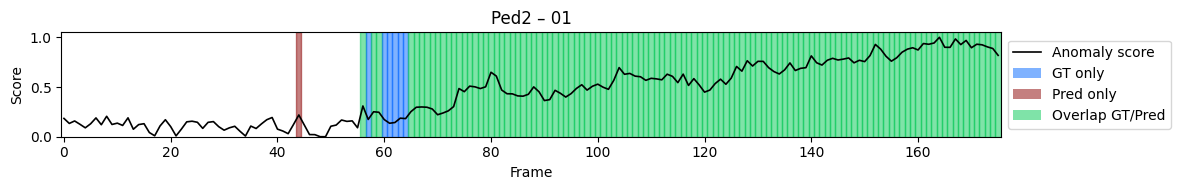

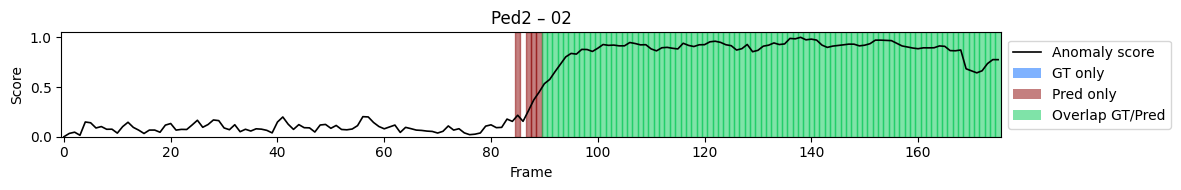

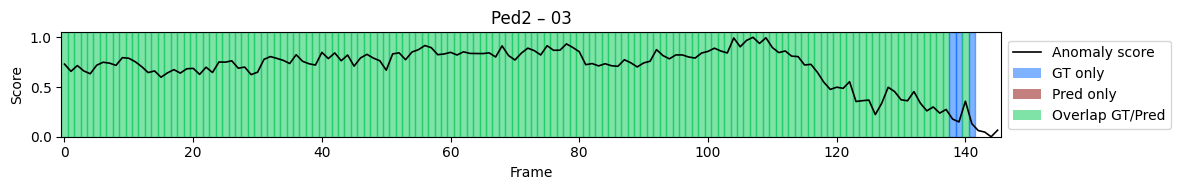

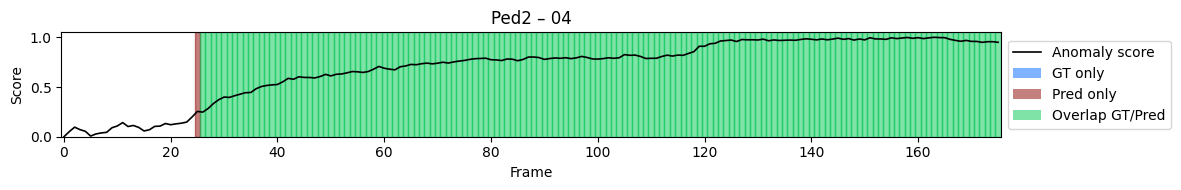

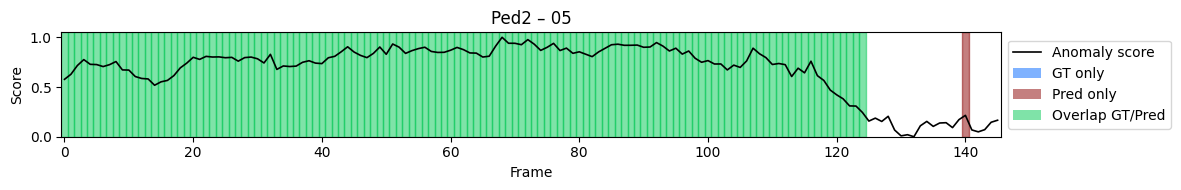

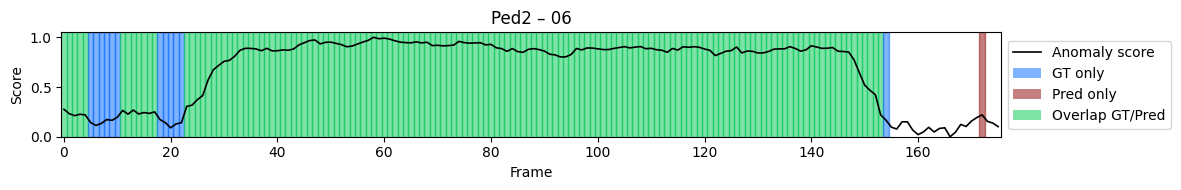

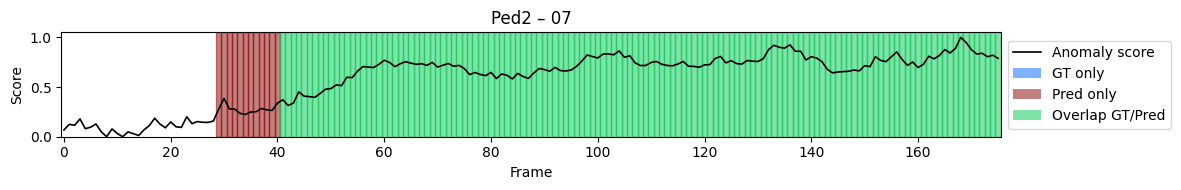

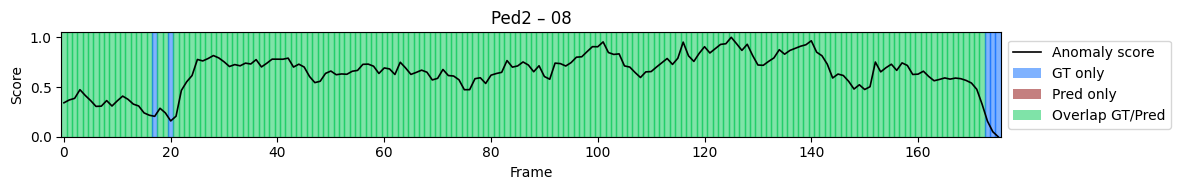

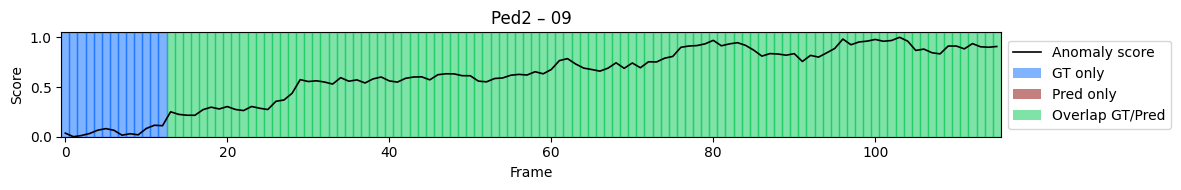

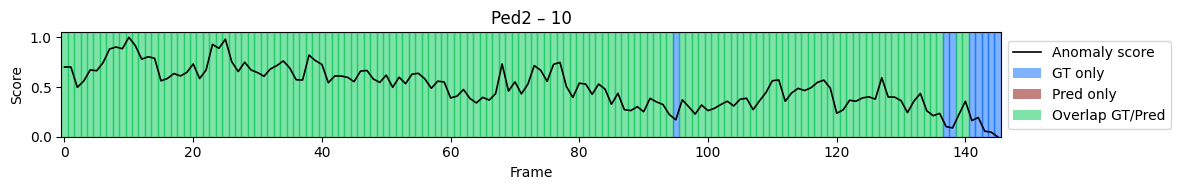

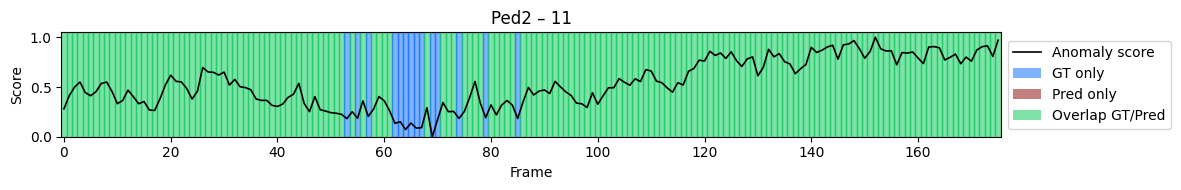

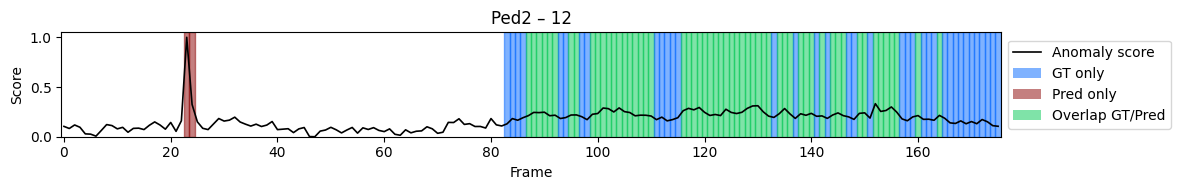

In [ ]:
def plot_video_ped2(idx, thr=best_thr):
    psnr_video = psnr_list[idx]
    score = anomaly_score_from_psnr(psnr_video)

    gt_aligned = align_gt_to_psnr(gt_list[idx], psnr_video, fp)
    pred = (score >= thr).astype(int)

    L = min(len(score), len(gt_aligned), len(pred))
    score = score[:L]
    gt_aligned = gt_aligned[:L]
    pred = pred[:L]

    name = video_names[idx] if idx < len(video_names) else f"{idx+1:02d}"

    # Crea array di colori basato sulla combinazione GT/Pred
    colors = np.empty(L, dtype=object)
    colors[:] = 'none'  # default: nessun riempimento

    # Priorità: overlap > GT only > Pred only
    colors[(gt_aligned == 1) & (pred == 0)] = '#0066FF'  # GT only (blu)
    colors[(pred == 1) & (gt_aligned == 0)] = '#8B0000'  # Pred only (rosso)
    colors[(gt_aligned == 1) & (pred == 1)] = '#00C853'  # Overlap (verde)

    fig, ax = plt.subplots(figsize=(12, 2.0))

    # Plot lo score
    ax.plot(score, color="black", linewidth=1.2, label="Anomaly score", zorder=3)

    # Fill con un solo ciclo per evitare sovrapposizioni
    for i in range(L):
        if colors[i] != 'none':
            ax.axvspan(i-0.5, i+0.5, ymin=0, ymax=1,
                       color=colors[i], alpha=0.5, zorder=1)

    # Crea le label per la legenda
    from matplotlib.patches import Patch
    legend_elements = [
        plt.Line2D([0], [0], color='black', linewidth=1.2, label='Anomaly score'),
        Patch(facecolor='#0066FF', alpha=0.5, label='GT only'),
        Patch(facecolor='#8B0000', alpha=0.5, label='Pred only'),
        Patch(facecolor='#00C853', alpha=0.5, label='Overlap GT/Pred')
    ]

    ax.set_title(f"Ped2 – {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, L-0.5)

    # Posiziona la legenda fuori dal plot, a destra
    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

for i in range(12):
    plot_video_ped2(i)

###ROC curve

N video psnr: 12
N video gt: 12
AUC complessiva (Ped2): 97.4%


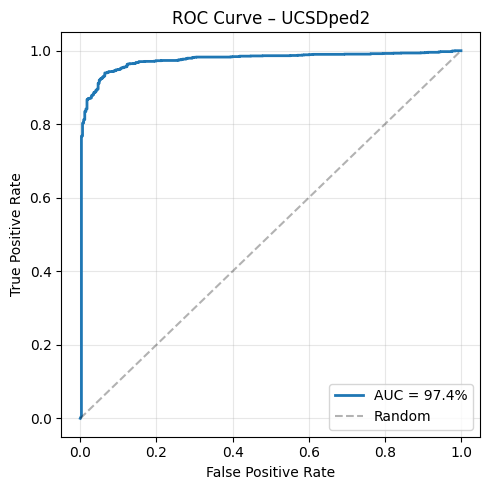

In [ ]:
OUT_DIR = Path("/content/astnet/ASTNet/output/ped2/ped2_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

print("N video psnr:", len(psnr_list))
print("N video gt:", len(gt_list))

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definizione funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola AUC
auc = roc_auc_score(all_gts, all_scores)
print(f"AUC complessiva (Ped2): {auc * 100:.1f}%")

# ROC
fpr, tpr, _ = roc_curve(all_gts, all_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc*100:.1f}%", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – UCSDped2")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Confusion Matrix

Soglia ottimale (Youden): 0.2065

=== METRICHE PED2 ===
Accuracy:  93.88%
Precision: 98.58%
Recall:    93.95%
F1-Score:  96.21%

Matrice di Confusione:
[[ 320   22]
 [  98 1522]]


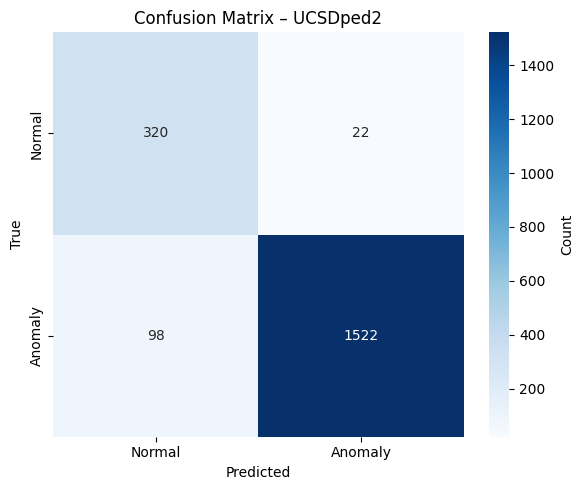


Dettagli:
True Negatives:  320
False Positives: 22
False Negatives: 98
True Positives:  1522


In [ ]:
OUT_DIR = Path("/content/astnet/ASTNet/output/ped2/ped2_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores e GT
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcolo della soglia ottimale (Youden index)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_gts, all_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Soglia ottimale (Youden): {best_threshold:.4f}")

# Predizioni binarie
y_pred = (all_scores >= best_threshold).astype(int)

# Calcola metriche
accuracy = accuracy_score(all_gts, y_pred)
precision = precision_score(all_gts, y_pred)
recall = recall_score(all_gts, y_pred)
f1 = f1_score(all_gts, y_pred)

print("\n=== METRICHE PED2 ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# Matrice di confusione
cm = confusion_matrix(all_gts, y_pred)
print("\nMatrice di Confusione:")
print(cm)

# Plot matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – UCSDped2')
plt.tight_layout()
plt.show()

# Dettagli matrice
tn, fp, fn, tp = cm.ravel()
print("\nDettagli:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

Per convertire gli anomaly score in predizioni binarie, è stata utilizzata una soglia ottimale calcolata mediante il criterio di Youden, che massimizza la differenza tra True Positive Rate e False Positive Rate.

##5.2 Synth


###Plot

*   Blu: gt originale
*   Rosso: predizione
*   Verde: sovrapposizione tra gt e predizione


In [ ]:
# Percorsi per il dataset sintetico
OUT_DIR = Path("/content/astnet/ASTNet/output/synth/synth_wresnet")
FRAMES_DIR = Path("/content/drive/MyDrive/datasets/Synth/split_80-20-20_astnet/testing/frames")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

video_names = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])

fp = 4  # encoded_frames + decoded_frames

#-------
# Score continuo
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)

    # caso tipico: gt lungo = Lp + fp (es 243 vs 239)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    # caso: gt già allineato
    if len(gt) == Lp:
        return gt
    # fallback: taglia/padda
    return gt[:Lp]

#-------
# Calcolo soglia globale dal ROC (Youden J)
#-------
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

fpr, tpr, thr = roc_curve(all_gts, all_scores)
best_thr = thr[np.argmax(tpr - fpr)]   # Youden J
print("Soglia globale (Youden) per Synth:", best_thr)

#-------
# Plot: blu=GT, rosso=prediction, verde=sovrapposizione dei due
#-------
def plot_video_synth(idx, thr=best_thr):
    psnr_video = psnr_list[idx]
    score = anomaly_score_from_psnr(psnr_video)

    gt_aligned = align_gt_to_psnr(gt_list[idx], psnr_video, fp)
    pred = (score >= thr).astype(int)

    L = min(len(score), len(gt_aligned), len(pred))
    score = score[:L]
    gt_aligned = gt_aligned[:L]
    pred = pred[:L]

    name = video_names[idx] if idx < len(video_names) else f"{idx+1:02d}"

    # Crea array di colori basato sulla combinazione GT/Pred
    colors = np.empty(L, dtype=object)
    colors[:] = 'none'  # default: nessun riempimento

    # Priorità: overlap > GT only > Pred only
    colors[(gt_aligned == 1) & (pred == 0)] = '#0066FF'  # GT only (blu)
    colors[(pred == 1) & (gt_aligned == 0)] = '#8B0000'  # Pred only (rosso)
    colors[(gt_aligned == 1) & (pred == 1)] = '#00C853'  # Overlap (verde)

    fig, ax = plt.subplots(figsize=(12, 2.0))

    # Plot lo score
    ax.plot(score, color="black", linewidth=1.2, label="Anomaly score", zorder=3)

    # Fill con un solo ciclo per evitare sovrapposizioni
    for i in range(L):
        if colors[i] != 'none':
            ax.axvspan(i-0.5, i+0.5, ymin=0, ymax=1,
                       color=colors[i], alpha=0.5, zorder=1)

    # Crea le label per la legenda
    legend_elements = [
        plt.Line2D([0], [0], color='black', linewidth=1.2, label='Anomaly score'),
        Patch(facecolor='#0066FF', alpha=0.5, label='GT only'),
        Patch(facecolor='#8B0000', alpha=0.5, label='Pred only'),
        Patch(facecolor='#00C853', alpha=0.5, label='Overlap GT/Pred')
    ]

    ax.set_title(f"Synth – {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, L-0.5)

    # Posizionamento della legenda fuori dal plot
    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Plotta tutti i video del dataset sintetico
num_videos = len(psnr_list)
print(f"Numero totale di video: {num_videos}")

for i in range(num_videos):
    plot_video_synth(i)

Output hidden; open in https://colab.research.google.com to view.

###ROC curve

N video psnr: 56
N video gt: 56
AUC complessiva (Synth): 52.2%


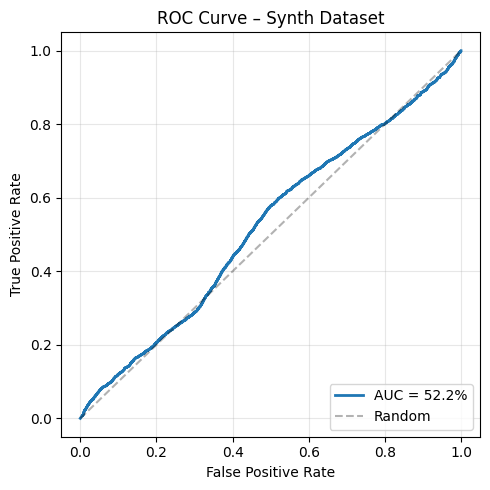

In [ ]:
OUT_DIR = Path("/content/astnet/ASTNet/output/synth/synth_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

print("N video psnr:", len(psnr_list))
print("N video gt:", len(gt_list))

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni qui
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola AUC
auc = roc_auc_score(all_gts, all_scores)
print(f"AUC complessiva (Synth): {auc * 100:.1f}%")

# ROC
fpr, tpr, _ = roc_curve(all_gts, all_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc*100:.1f}%", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Synth Dataset")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Confusion Matrix

Soglia ottimale (Youden): 0.3414

=== METRICHE SYNTH ===
Accuracy:  51.85%
Precision: 25.88%
Recall:    57.73%
F1-Score:  35.74%

Matrice di Confusione:
[[5148 5132]
 [1312 1792]]


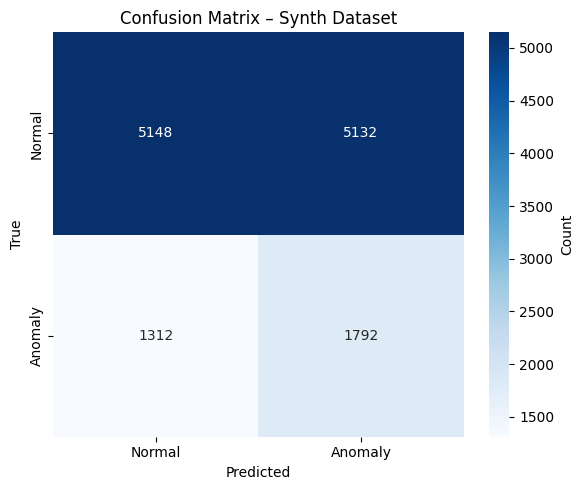


Dettagli:
True Negatives:  5148
False Positives: 5132
False Negatives: 1312
True Positives:  1792


In [ ]:
OUT_DIR = Path("/content/astnet/ASTNet/output/synth/synth_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcolo degli scores e GT
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola soglia ottimale (Youden index)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_gts, all_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Soglia ottimale (Youden): {best_threshold:.4f}")

# Predizioni binarie
y_pred = (all_scores >= best_threshold).astype(int)

# Calcola metriche
accuracy = accuracy_score(all_gts, y_pred)
precision = precision_score(all_gts, y_pred)
recall = recall_score(all_gts, y_pred)
f1 = f1_score(all_gts, y_pred)

print("\n=== METRICHE SYNTH ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# Matrice di confusione
cm = confusion_matrix(all_gts, y_pred)
print("\nMatrice di Confusione:")
print(cm)

# Plot matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – Synth Dataset')
plt.tight_layout()
plt.show()

# Stampa dettagli matrice
tn, fp, fn, tp = cm.ravel()
print("\nDettagli:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

##5.3 MED

###Plot


*   Blu: gt originale
*   Rosso: predizione
*   Verde: sovrapposizione tra gt e predizione

Soglia globale (Youden) per MED: 0.4408460180301117
Numero totale di video: 31


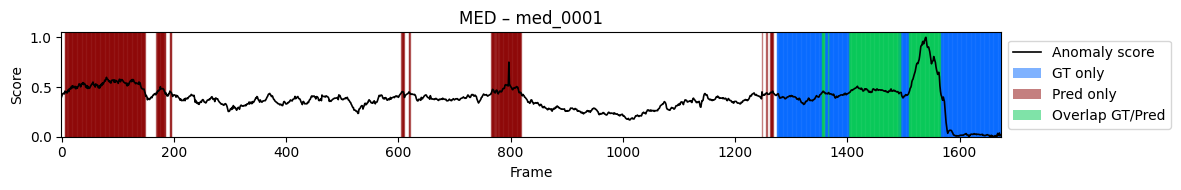

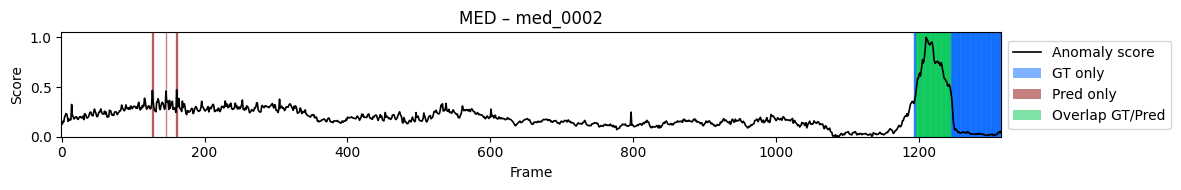

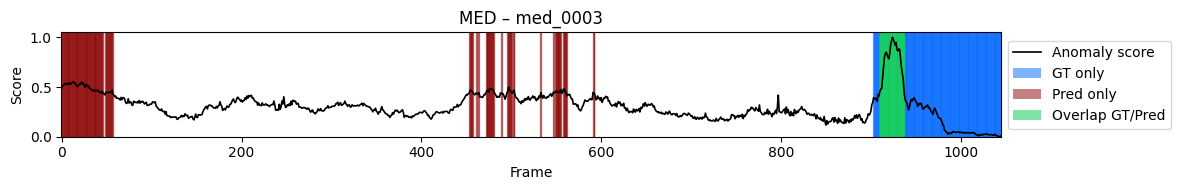

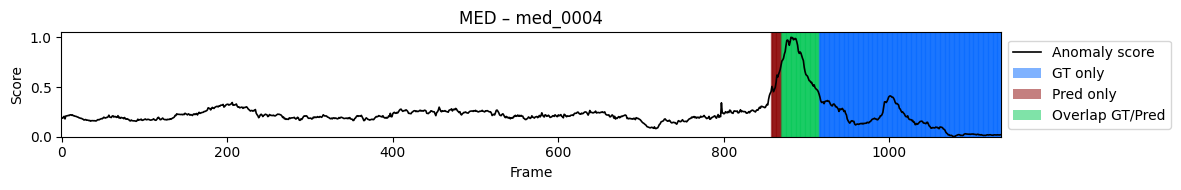

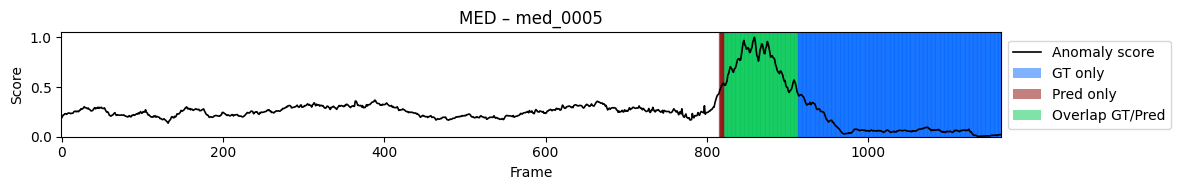

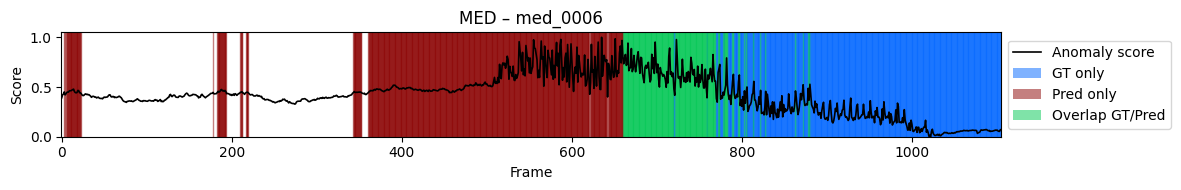

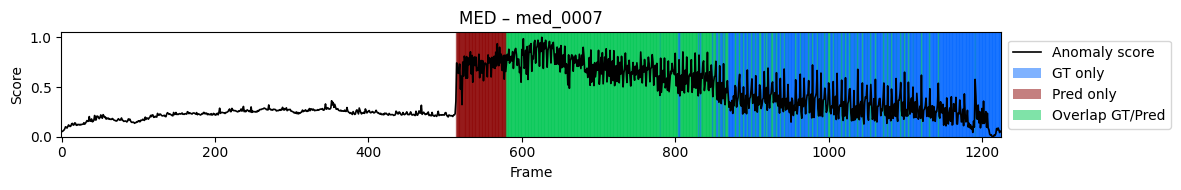

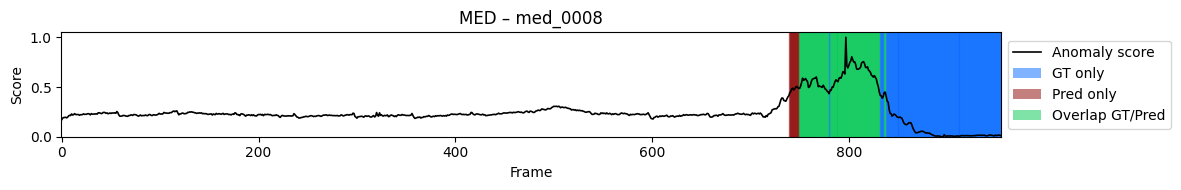

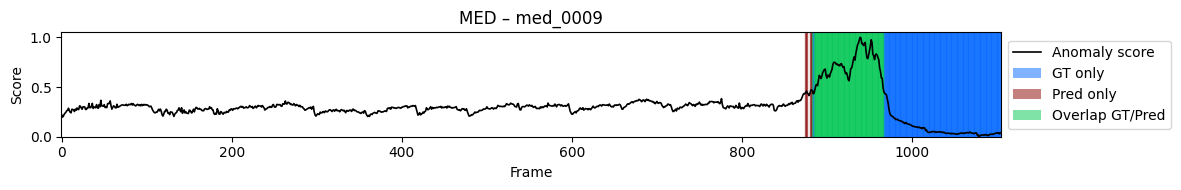

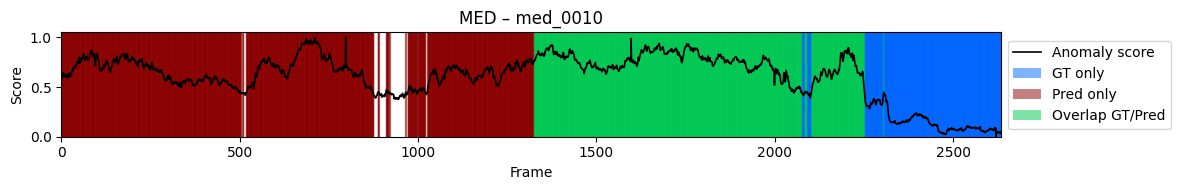

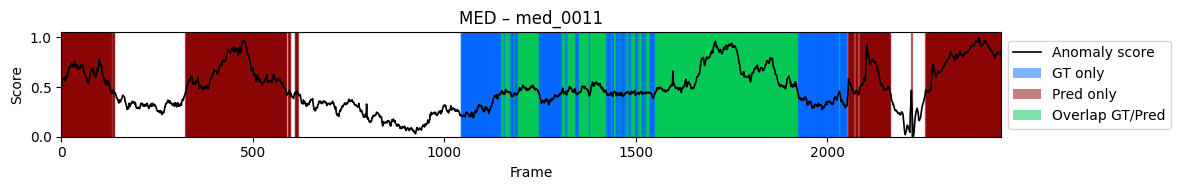

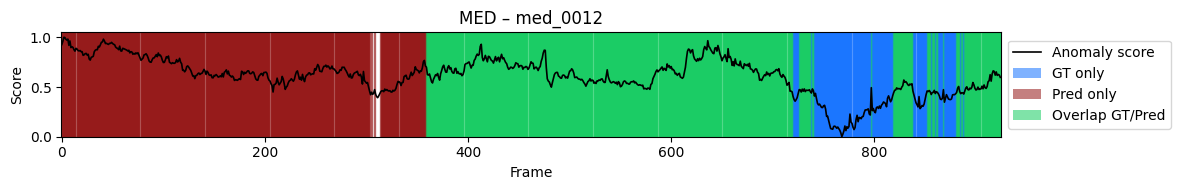

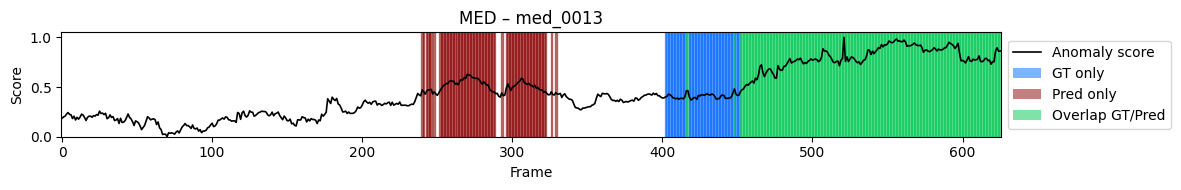

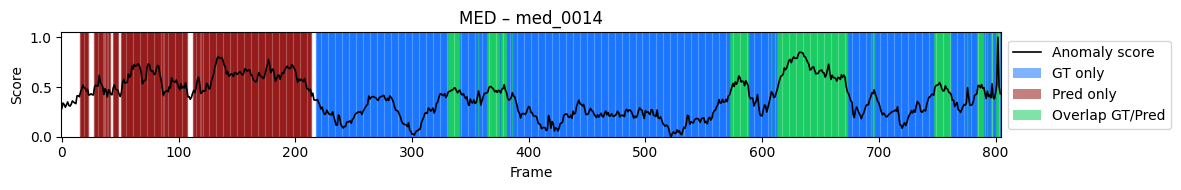

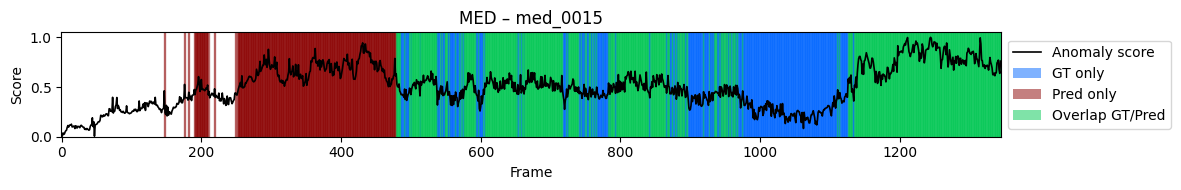

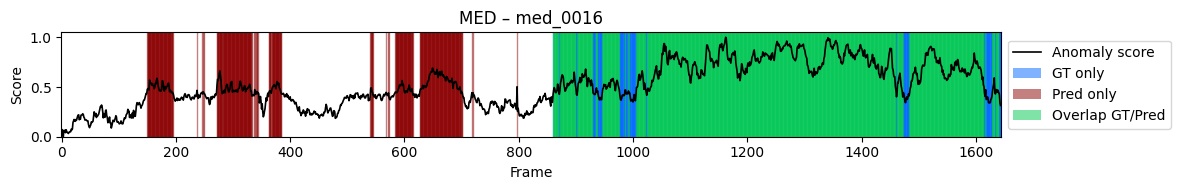

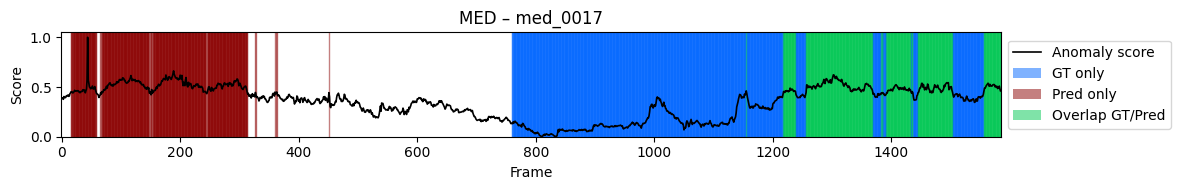

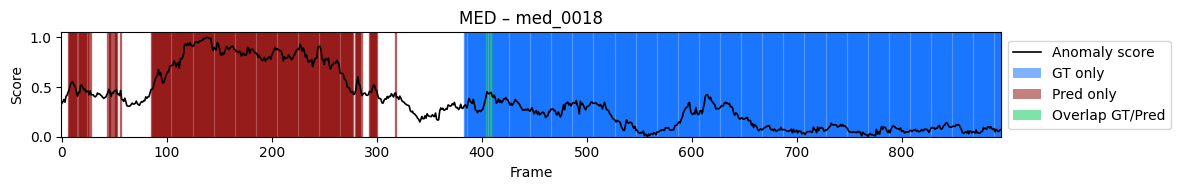

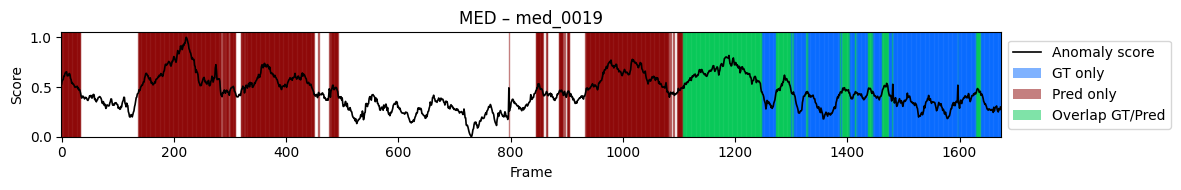

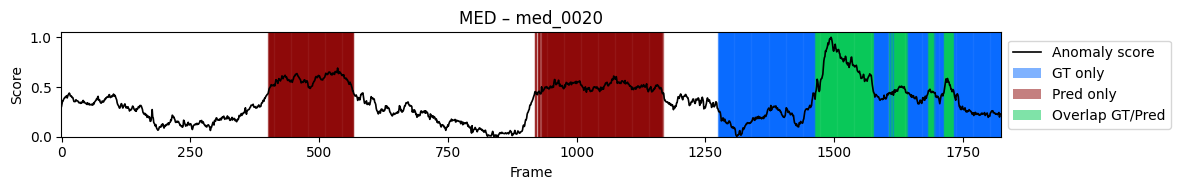

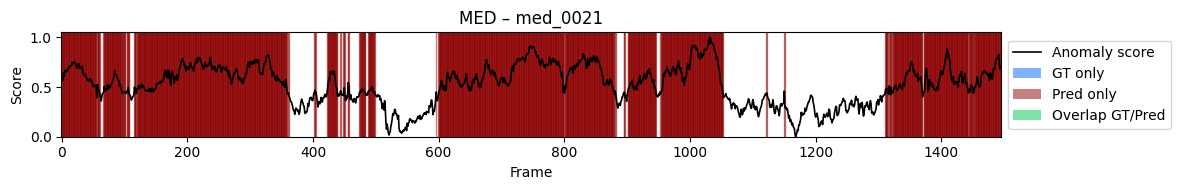

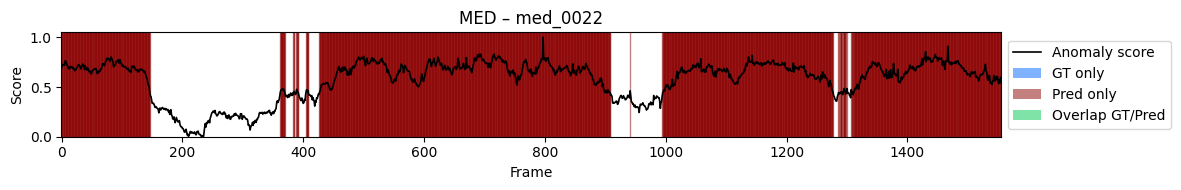

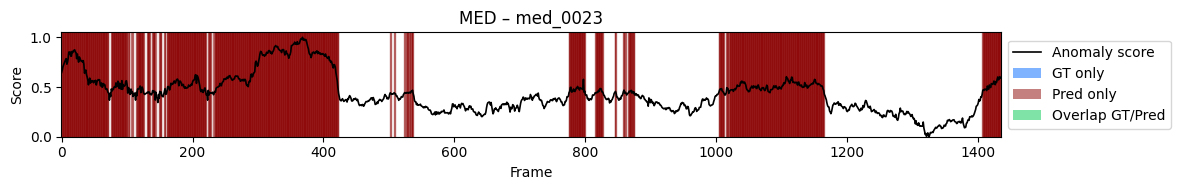

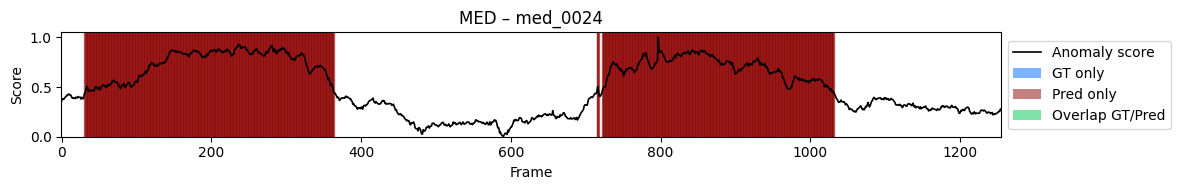

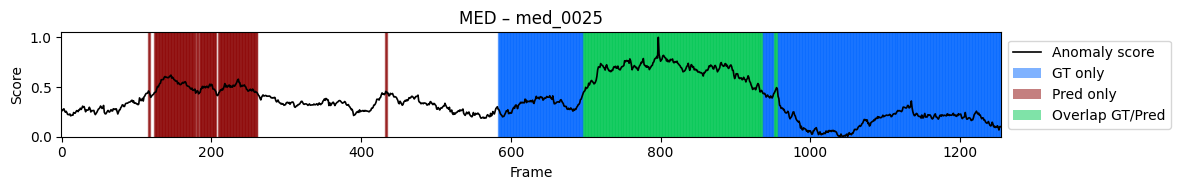

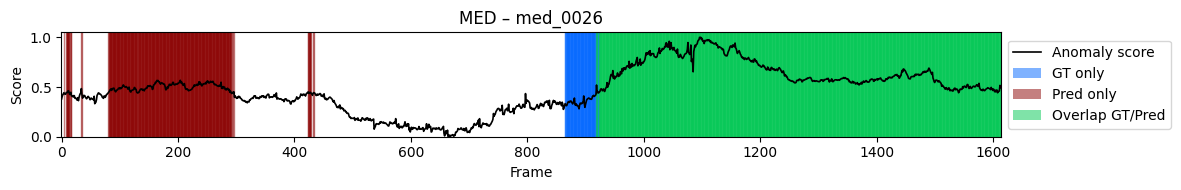

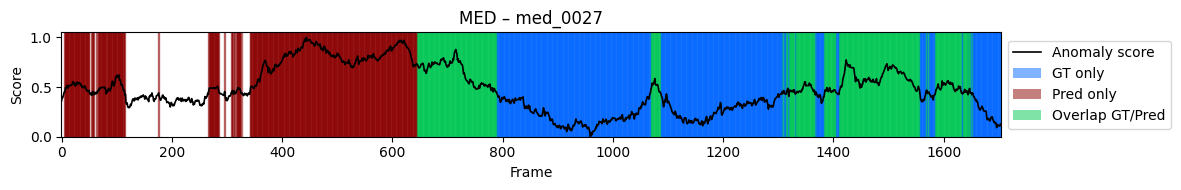

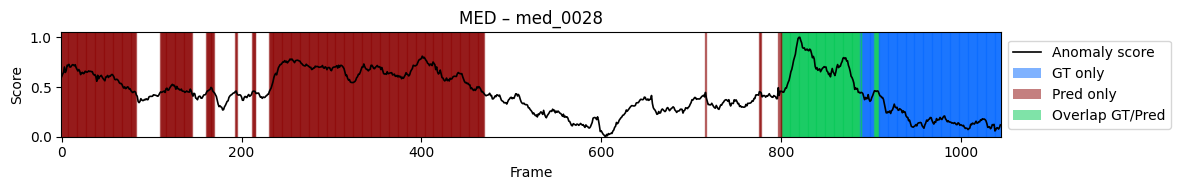

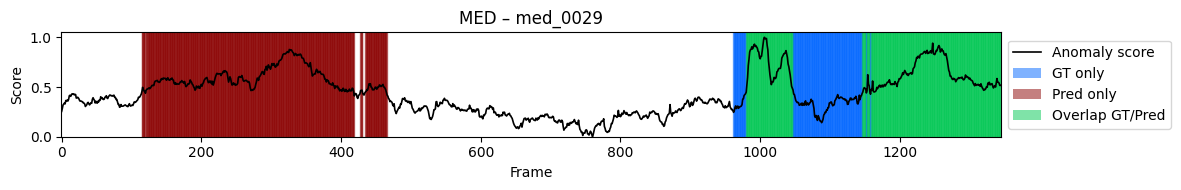

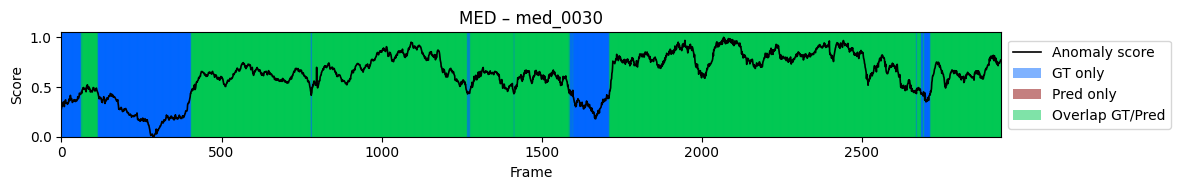

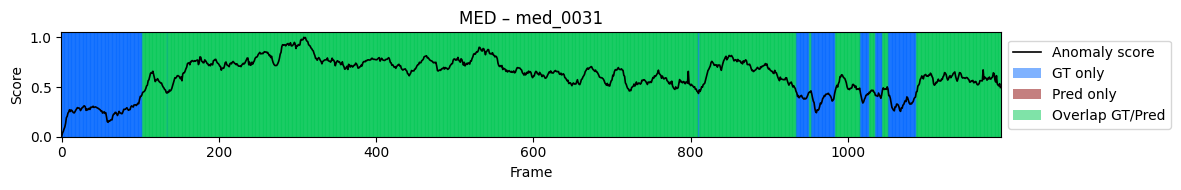

In [ ]:
# Percorsi per il dataset MED
OUT_DIR = Path("/content/astnet/ASTNet/output/med/med_wresnet")
FRAMES_DIR = Path("/content/drive/MyDrive/datasets/med/testing/frames")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

video_names = sorted([p.name for p in FRAMES_DIR.iterdir() if p.is_dir()])

fp = 4  # encoded_frames + decoded_frames

#-------
# Score continuo
#-------
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)

    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

#-------
# Calcolo soglia globale dal ROC (Youden J)
#-------
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

fpr, tpr, thr = roc_curve(all_gts, all_scores)
best_thr = thr[np.argmax(tpr - fpr)]
print("Soglia globale (Youden) per MED:", best_thr)

#-------
# Plot
#-------
def plot_video_med(idx, thr=best_thr):
    psnr_video = psnr_list[idx]
    score = anomaly_score_from_psnr(psnr_video)

    gt_aligned = align_gt_to_psnr(gt_list[idx], psnr_video, fp)
    pred = (score >= thr).astype(int)

    L = min(len(score), len(gt_aligned), len(pred))
    score = score[:L]
    gt_aligned = gt_aligned[:L]
    pred = pred[:L]

    name = video_names[idx] if idx < len(video_names) else f"{idx+1:02d}"

    colors = np.empty(L, dtype=object)
    colors[:] = 'none'

    # Blu: Anomalia reale non vista (False Negative)
    colors[(gt_aligned == 1) & (pred == 0)] = '#0066FF'
    # Rosso: Allarme dove non c'è anomalia (False Positive)
    colors[(pred == 1) & (gt_aligned == 0)] = '#8B0000'
    # Verde: Anomalia rilevata correttamente (True Positive)
    colors[(gt_aligned == 1) & (pred == 1)] = '#00C853'

    fig, ax = plt.subplots(figsize=(12, 2.0))

    ax.plot(score, color="black", linewidth=1.2, label="Anomaly score", zorder=3)
    ax.axhline(y=thr, color='red', linestyle='--', linewidth=1, label='Soglia', zorder=2)

    for i in range(L):
        if colors[i] != 'none':
            ax.axvspan(i-0.5, i+0.5, ymin=0, ymax=1,
                       color=colors[i], alpha=0.5, zorder=1)

    legend_elements = [
        plt.Line2D([0], [0], color='black', linewidth=1.2, label='Anomaly score'),
        Patch(facecolor='#0066FF', alpha=0.4, label='Solo Ground Truth'),
        Patch(facecolor='#8B0000', alpha=0.4, label='Solo Predizione (FP)'),
        Patch(facecolor='#00C853', alpha=0.4, label='Rilevamento Corretto')
    ]

    ax.set_title(f"MED – {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xlim(-0.5, L-0.5)

    ax.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# Plotta tutti i video
num_videos = len(psnr_list)
print(f"Numero totale di video: {num_videos}")

for i in range(num_videos):
    plot_video_med(i)  # ← CORRETTO

###ROC curve

N video psnr: 31
N video gt: 31
AUC complessiva (MED): 59.4%


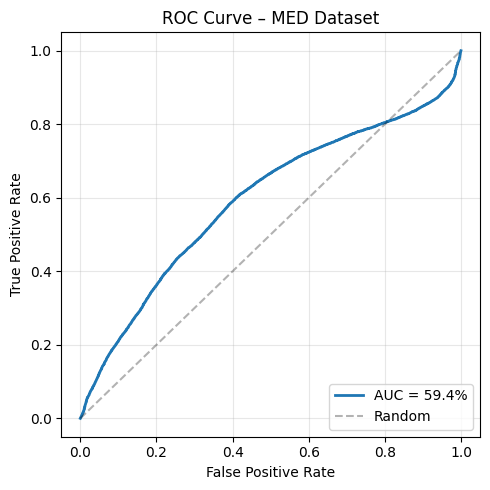

In [ ]:
OUT_DIR = Path("/content/astnet/ASTNet/output/med/med_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

print("N video psnr:", len(psnr_list))
print("N video gt:", len(gt_list))

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definisci le funzioni qui
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcola scores
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola AUC
auc = roc_auc_score(all_gts, all_scores)
print(f"AUC complessiva (MED): {auc * 100:.1f}%")

# ROC
fpr, tpr, _ = roc_curve(all_gts, all_scores)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc*100:.1f}%", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MED Dataset")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Confusion Matrix

Soglia ottimale (Youden): 0.4408

=== METRICHE MED ===
Accuracy:  59.81%
Precision: 50.35%
Recall:    58.19%
F1-Score:  53.99%

Matrice di Confusione:
[[15929 10222]
 [ 7449 10367]]


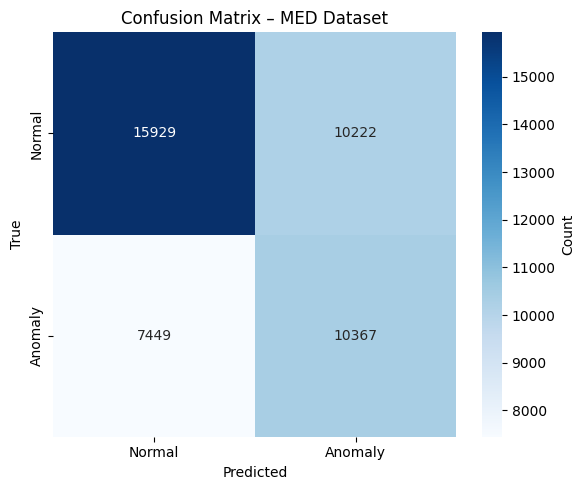


Dettagli:
True Negatives:  15929
False Positives: 10222
False Negatives: 7449
True Positives:  10367


In [ ]:
OUT_DIR = Path("/content/astnet/ASTNet/output/med/med_wresnet")

psnr_list = np.load(OUT_DIR / "psnr_list.npy", allow_pickle=True)
gt_list   = np.load(OUT_DIR / "gt_list.npy", allow_pickle=True)

fp = 4  # ENCODED_FRAMES + DECODED_FRAMES

# Definizione funzioni
def anomaly_score_from_psnr(psnr_video):
    psnr_video = np.asarray(psnr_video, dtype=float)
    psnr_norm = (psnr_video - psnr_video.min()) / (psnr_video.max() - psnr_video.min() + 1e-12)
    return 1.0 - psnr_norm

def align_gt_to_psnr(gt_video, psnr_video, fp=4):
    gt = np.asarray(gt_video).astype(int).ravel()
    Lp = len(psnr_video)
    if len(gt) == Lp + fp:
        return gt[fp:fp+Lp]
    if len(gt) == Lp:
        return gt
    return gt[:Lp]

# Calcolo degli scores e GT
all_scores = []
all_gts = []

for psnr_video, gt_video in zip(psnr_list, gt_list):
    score = anomaly_score_from_psnr(psnr_video)
    gt_aligned = align_gt_to_psnr(gt_video, psnr_video, fp)

    L = min(len(score), len(gt_aligned))
    all_scores.append(score[:L])
    all_gts.append(gt_aligned[:L])

all_scores = np.concatenate(all_scores)
all_gts = np.concatenate(all_gts)

# Calcola soglia ottimale (Youden index)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_gts, all_scores)
best_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Soglia ottimale (Youden): {best_threshold:.4f}")

# Predizioni binarie
y_pred = (all_scores >= best_threshold).astype(int)

# Calcola metriche
accuracy = accuracy_score(all_gts, y_pred)
precision = precision_score(all_gts, y_pred)
recall = recall_score(all_gts, y_pred)
f1 = f1_score(all_gts, y_pred)

print("\n=== METRICHE MED ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

# Matrice di confusione
cm = confusion_matrix(all_gts, y_pred)
print("\nMatrice di Confusione:")
print(cm)

# Plot matrice di confusione
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – MED Dataset')
plt.tight_layout()
plt.show()

# Stampa dettagli matrice
tn, fp, fn, tp = cm.ravel()
print("\nDettagli:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

#6-Recap results

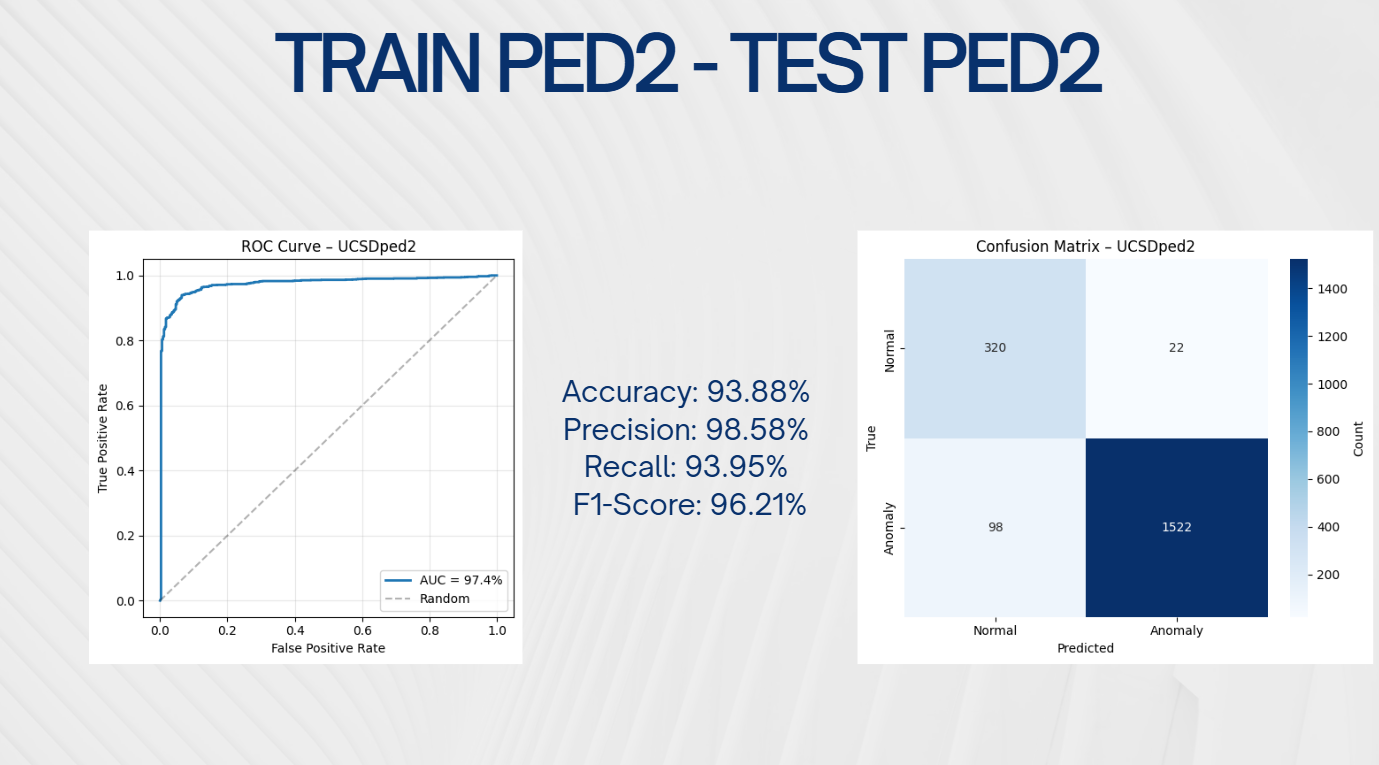

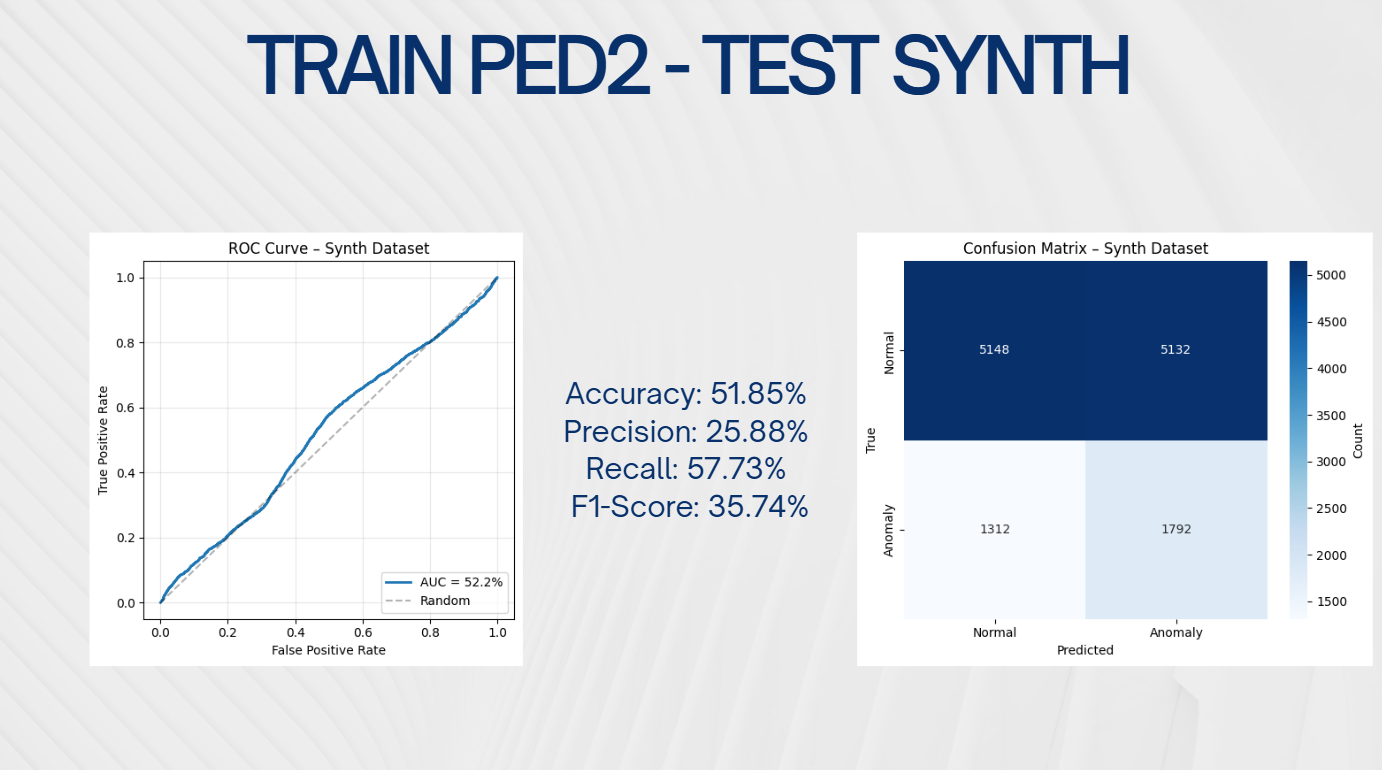

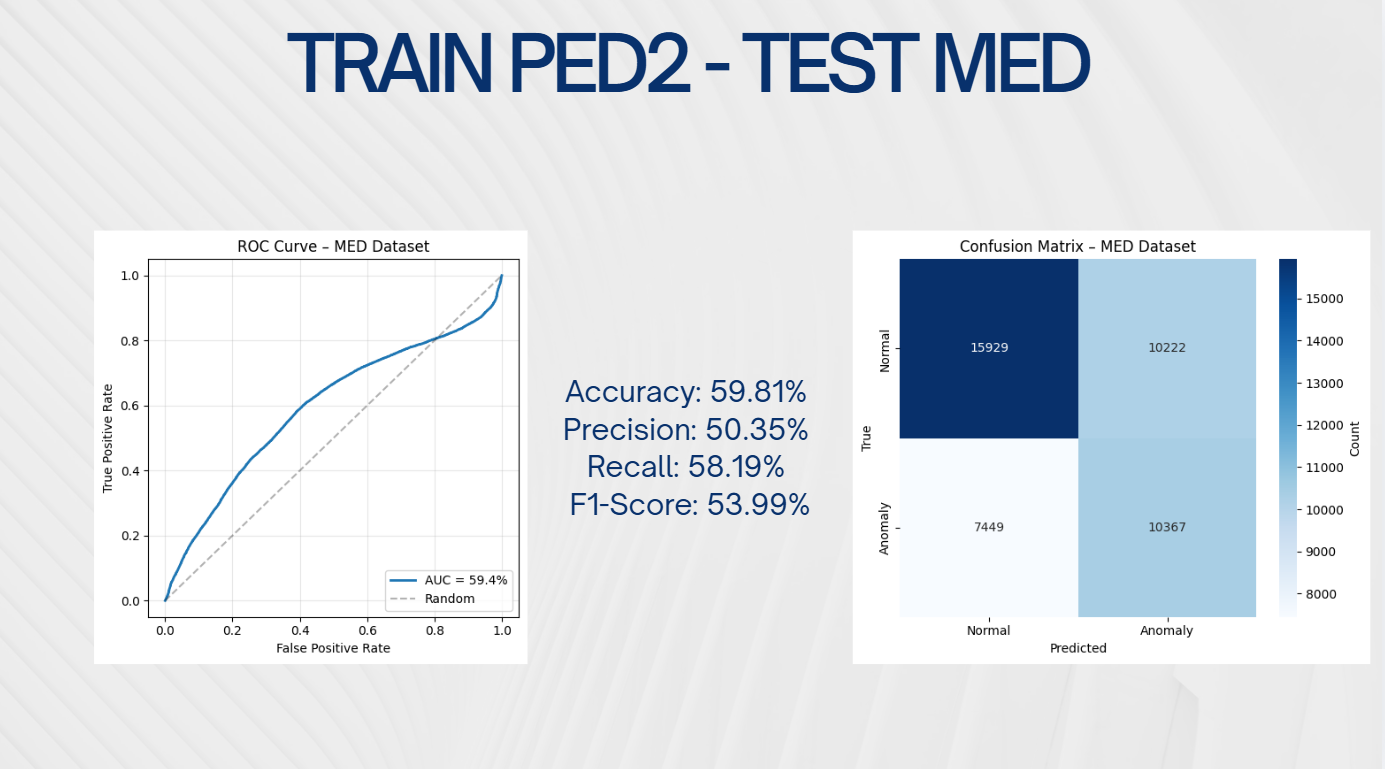